# SONAR Benchmark Analysis

This notebook loads pre-computed benchmark results and reproduces the analysis
from the SONAR paper (Piridi et al., submitted to SIGIR 2026).

## 1. Load Results

In [1]:
import json
import pandas as pd

def load_results(path):
    with open(path) as f:
        return pd.DataFrame(json.load(f))

small = load_results("../results/small_detectors_results.json")
print(f"Small: {len(small)} detectors")

Small: 16 detectors


## 2. Paper Table 5: Small Dataset Results

In [2]:
# Reproduce Paper Table 5
table5 = small[["algorithm", "roc_auc", "average_precision", "recall_at_1818"]].copy()
table5.columns = ["Detector", "ROC-AUC", "Avg Precision", "Recall@1818"]
table5 = table5.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
table5

,Detector,ROC-AUC,Avg Precision,Recall@1818
0,AdONE,0.8459,0.1672,0.0875
1,DONE,0.8407,0.1599,0.0721
2,GAE,0.8025,0.1806,0.1518
3,ANOMALOUS,0.7997,0.4305,0.4455
4,Radar,0.7997,0.4305,0.4455
5,SCAN,0.7526,0.5223,0.5198
6,DOMINANT,0.7384,0.0825,0.0286
7,CONAD,0.7375,0.0824,0.0292
8,AnomalyDAE,0.6858,0.2569,0.3388
9,IF,0.6518,0.1381,0.1865


## 3. Performance Visualization

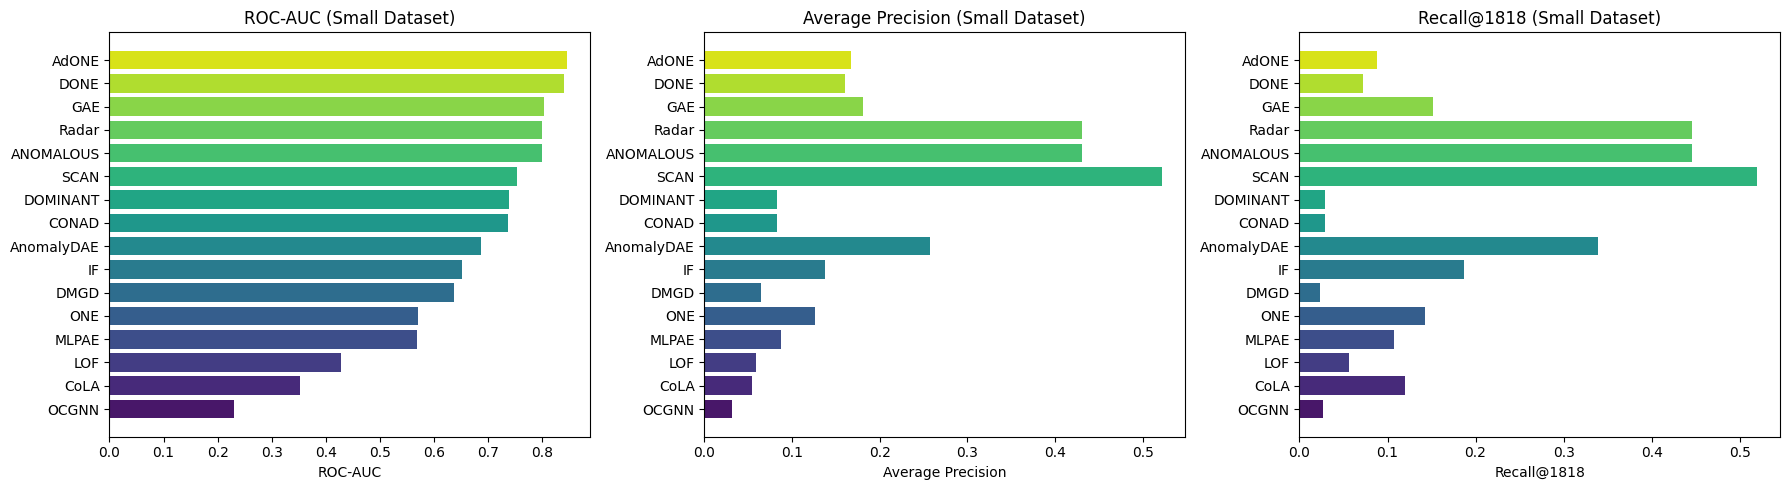

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [("roc_auc", "ROC-AUC"), ("average_precision", "Average Precision"),
           ("recall_at_1818", "Recall@1818")]

sorted_small = small.sort_values("roc_auc", ascending=True)

for ax, (col, title) in zip(axes, metrics):
    ax.barh(sorted_small["algorithm"], sorted_small[col],
            color=sns.color_palette("viridis", len(sorted_small)))
    ax.set_xlabel(title)
    ax.set_title(f"{title} (Small Dataset)")

plt.tight_layout()
plt.show()

## 4. Training Time

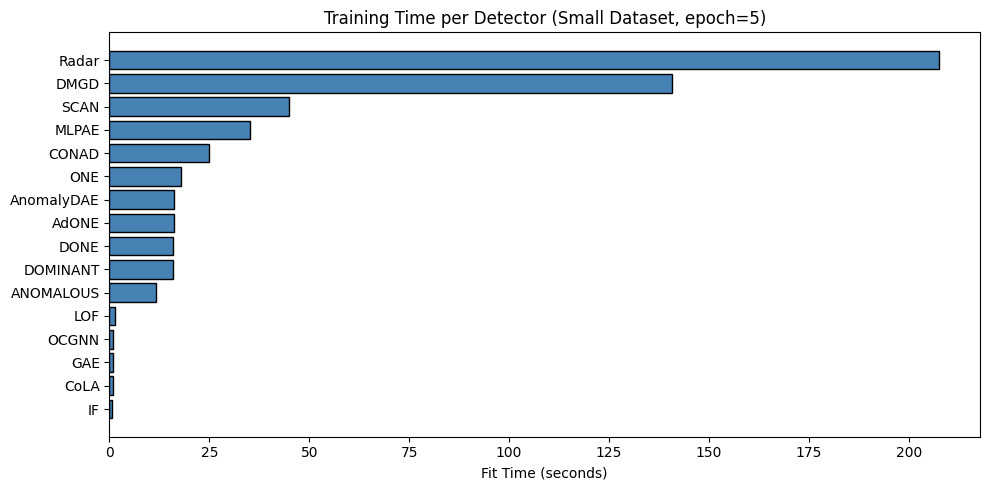

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

sorted_time = small.sort_values("fit_time_seconds", ascending=True)
ax.barh(sorted_time["algorithm"], sorted_time["fit_time_seconds"],
        color="steelblue", edgecolor="black")
ax.set_xlabel("Fit Time (seconds)")
ax.set_title("Training Time per Detector (Small Dataset, epoch=5)")

plt.tight_layout()
plt.show()

## 5. Adding a New Detector

To add a new detector to the benchmark:

```bash
uv run python run_detector.py \
    --dataset-name small \
    --algorithm YOUR_DETECTOR \
    --output results/small_detectors_results.json \
    --epoch 5
```

The results JSON will be updated with the new entry. Then re-run this notebook
to see the updated analysis.